### Download raw data

In [1]:
import dgeb
from datasets import load_dataset
import numpy as np

/Users/teeratc/Desktop/2026 Spring/CS690U/CS690U-DGEB-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ecoli_rna_data = load_dataset("tattabio/e_coli_rnas")
mopb_data = load_dataset("tattabio/mopb_clustering")

In [3]:
ecoli_rna_data

DatasetDict({
    train: Dataset({
        features: ['Sequence', 'Label'],
        num_rows: 161
    })
})

In [4]:
mopb_data

DatasetDict({
    train: Dataset({
        features: ['Entry', 'Sequence', 'Label'],
        num_rows: 1300
    })
})

### Embedding data

In [5]:
esm2_model = dgeb.get_model("facebook/esm2_t6_8M_UR50D") # 320-dimensional embeddings for e_coli

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
ntv2_model = dgeb.get_model("InstaDeepAI/nucleotide-transformer-v2-50m-multi-species") # 512-dimensional embeddings for mopb

In [7]:
def embed_dataset(data, model, dataset_name):
    sequences = data["train"]["Sequence"]
    labels = data["train"]["Label"]
    
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = model.encode([seq])
        embeddings.append(emb[0])
        print(i)

    embeddings = np.array(embeddings)
    print(embeddings.shape)

    np.savez(
        f"Encoded_Data/{dataset_name}_embeddings.npz",
        embeddings=embeddings,
        labels=np.array(labels)
    )
    
    return np.array(embeddings)

In [8]:
embed_dataset(ecoli_rna_data, esm2_model, "ecoli_rna")

/Users/teeratc/Desktop/2026 Spring/CS690U/CS690U-DGEB-project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 14 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/Users/teeratc/Desktop/2026 Spring/CS690U/CS690U-DGEB-project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 14 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get Data

0


/Users/teeratc/Desktop/2026 Spring/CS690U/CS690U-DGEB-project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 14 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/Users/teeratc/Desktop/2026 Spring/CS690U/CS690U-DGEB-project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 14 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get Data

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
(161, 2, 320)


array([[[ 4.7948274e-01,  1.4980154e-01, -7.5339150e-01, ...,
          7.6201484e-02, -3.4525317e-01,  1.4992255e+00],
        [ 2.3356562e+00,  1.6125329e+00, -1.5598477e+00, ...,
         -8.1502098e-01,  9.5601529e-01, -6.0822105e-01]],

       [[ 4.6463346e-01,  2.0526923e-01, -8.2289380e-01, ...,
         -1.4048544e-02, -3.2731757e-01,  1.5046958e+00],
        [ 2.2234964e+00,  1.7181773e+00, -1.6390903e+00, ...,
         -7.8978103e-01,  1.0186884e+00, -7.6781309e-01]],

       [[ 4.3535519e-01,  3.0630797e-01, -8.0599558e-01, ...,
         -1.2366592e-01, -2.7574363e-01,  1.5816758e+00],
        [ 2.1902416e+00,  2.1384571e+00, -1.7816908e+00, ...,
         -4.7928324e-01,  7.3637629e-01, -7.6679629e-01]],

       ...,

       [[ 4.4948065e-01,  3.3160767e-01, -8.6917096e-01, ...,
         -1.1527413e-01, -3.6310917e-01,  1.5618867e+00],
        [ 2.3563943e+00,  2.1214280e+00, -1.5029849e+00, ...,
         -7.0485866e-01,  6.2365645e-01, -7.4520385e-01]],

       [[ 5.6521839

In [9]:
embed_dataset(mopb_data, ntv2_model, "mopb")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

array([[[-2.458367  , -0.89840466,  0.43978795, ..., -2.163298  ,
         -0.6658307 , -0.39873347],
        [-1.1115195 , -1.5710634 ,  0.4698047 , ..., -3.4421914 ,
         -2.803029  , -1.881247  ]],

       [[-2.0679717 , -1.0312836 ,  0.5872863 , ..., -2.2800245 ,
         -0.61264515, -0.14461172],
        [-1.4801419 , -2.2594645 ,  0.32912648, ..., -3.0432463 ,
         -3.0568159 , -2.6320145 ]],

       [[-2.402477  , -0.92357093,  0.5217868 , ..., -2.188488  ,
         -0.60913146, -0.23450097],
        [-1.4483546 , -1.7370708 ,  0.48952052, ..., -3.3349874 ,
         -2.9218316 , -2.2300413 ]],

       ...,

       [[-2.211856  , -1.0301691 ,  0.4093439 , ..., -2.1800177 ,
         -0.62323445, -0.53009653],
        [-1.2322307 , -1.2571752 ,  0.64675397, ..., -3.0123608 ,
         -2.3766067 , -2.4932554 ]],

       [[-2.327558  , -1.0064601 ,  0.50306505, ..., -2.204431  ,
         -0.65932494, -0.41202205],
        [-1.1485343 , -1.699294  ,  0.40745234, ..., -3.48283

### One-hot encoding data

In [16]:
def onehot_encode_dataset(data, dataset_name, type="NA"):
    sequences = data["train"]["Sequence"]
    labels = data["train"]["Label"]

    if type == "NA":
        alphabet = ["A", "C", "G", "T"]
    elif type == "AA":
        alphabet = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y", "X", "U"]
    else:
        raise ValueError("type must be 'NA' or 'AA'")

    char_to_id = {ch: i for i, ch in enumerate(alphabet)}
    vocab_size = len(alphabet)

    encoded_sequences = []

    for seq in sequences:
        seq = seq.upper()
        one_hot = np.zeros((len(seq), vocab_size))

        for i, ch in enumerate(seq):
            one_hot[i, char_to_id[ch]] = 1

        flat = one_hot.flatten()
        encoded_sequences.append(flat)

    max_len = max(len(vec) for vec in encoded_sequences)

    padded = np.array([
        np.pad(vec, (0, max_len - len(vec)), mode='constant')
        for vec in encoded_sequences
    ])

    print(padded.shape)

    np.savez(
        f"Encoded_Data/{dataset_name}_onehot_encoded.npz",
        embeddings=padded,
        labels=np.array(labels)
    )

    return padded

In [17]:
onehot_encode_dataset(ecoli_rna_data, "ecoli_rna", type="NA")

(161, 400)


array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.]], shape=(161, 400))

In [18]:
onehot_encode_dataset(mopb_data, "mopb", type="AA")

(1300, 28600)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1300, 28600))

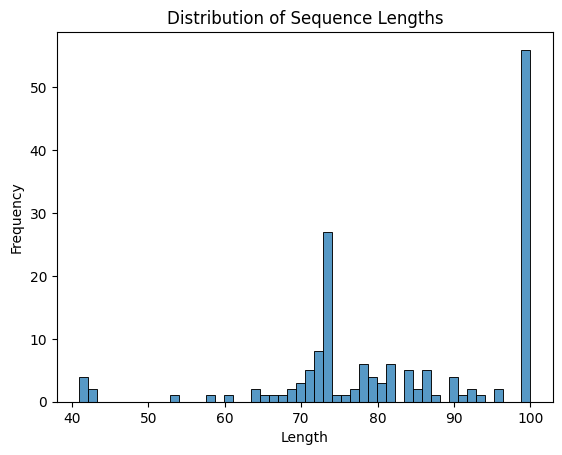

In [22]:
from matplotlib import pyplot as plt
import seaborn as sns
lengths = [len(seq) for seq in ecoli_rna_data["train"]["Sequence"]]
sns.histplot(lengths, bins=50)
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

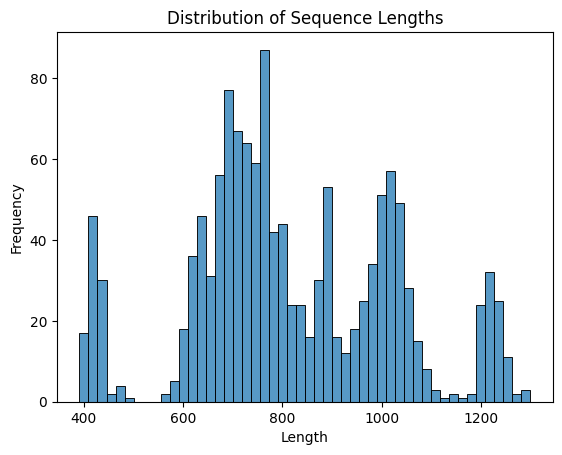

In [23]:
from matplotlib import pyplot as plt
import seaborn as sns
lengths = [len(seq) for seq in mopb_data["train"]["Sequence"]]
sns.histplot(lengths, bins=50)
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()